In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\viswa\Downloads\Housing.csv")
print("First 10 Rows:")
df.head(10)

First 10 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print("No of Rows and Columns")
df.shape

No of Rows and Columns


(545, 13)

In [5]:
print("Columns")
df.columns.tolist()

Columns


['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

In [6]:
target = "price"
features = [col for col in df.columns if col != target]
print("\nTarget Column:", target)
print("Feature Columns:", features)


Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [7]:
print("Missing Values in each column:")
df.isnull().sum()

Missing Values in each column:


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
data = df.copy()
data = data.drop_duplicates()
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())
categorical_columns = data.select_dtypes(include = ["object"]).columns
data = pd.get_dummies(data,
                      columns=categorical_columns,
                      drop_first=True)

print("Cleaned Dataset Shape:", data.shape)
display(data.head())

Cleaned Dataset Shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
x = data.drop("price", axis=1)
y = data["price"]
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.20, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_model = model.predict(x_test)
mae_lr = mean_absolute_error(y_test, y_pred_model)
msr_lr = np.sqrt(mean_squared_error(y_test, y_pred_model))
r2_lr = r2_score(y_test, y_pred_model)
print("Linear Regression Results:")
print("MAE:", mae_lr)
print("RSME:", msr_lr)
print("R2 Score:", r2_lr)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
msr_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("\nRandom Forest Regressor Results:")
print("MAE:",mae_rf)
print("RSME:", msr_rf)
print("R2 Score:", r2_rf)
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [msr_lr, msr_rf],
    "R2 Score": [r2_lr, r2_rf]
})
display(results)

Linear Regression Results:
MAE: 970043.4039201637
RSME: 1324506.9600914388
R2 Score: 0.6529242642153184

Random Forest Regressor Results:
MAE: 1013968.579587156
RSME: 1398115.6668385956
R2 Score: 0.6132752494107068


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


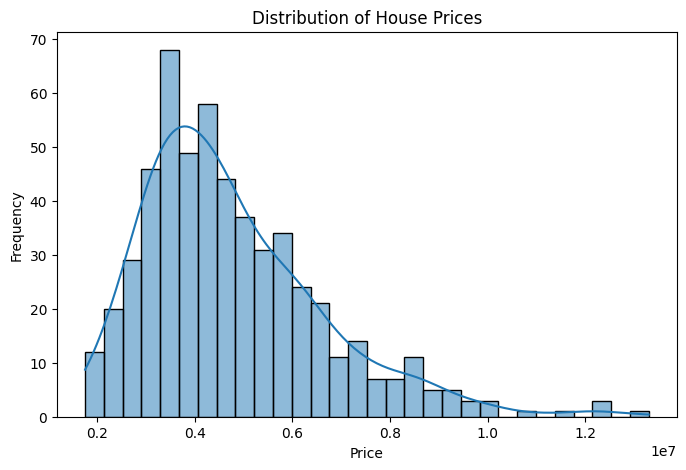

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(data=data, x="price", bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

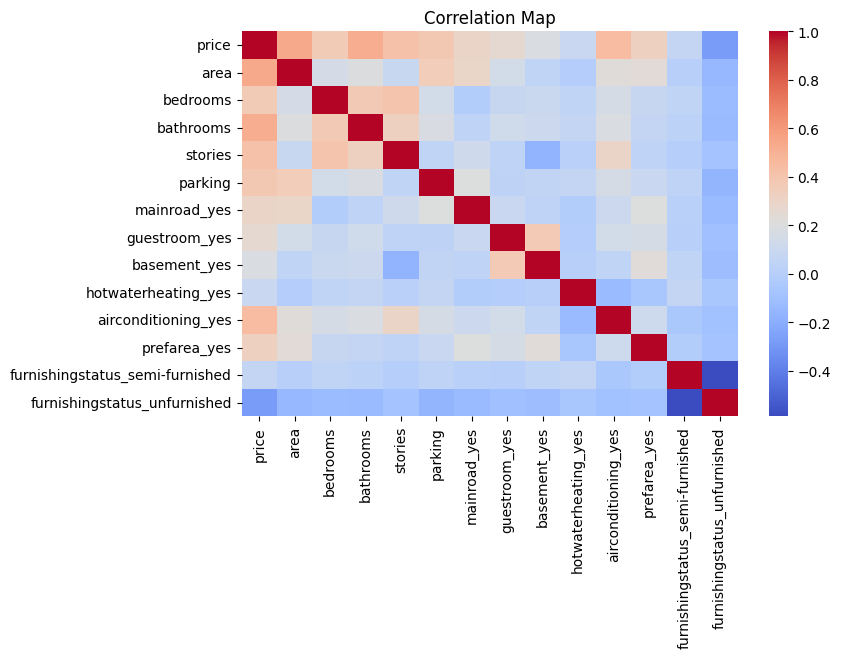

In [11]:
plt.figure(figsize=(8,5))
corr = data.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Map")
plt.show()

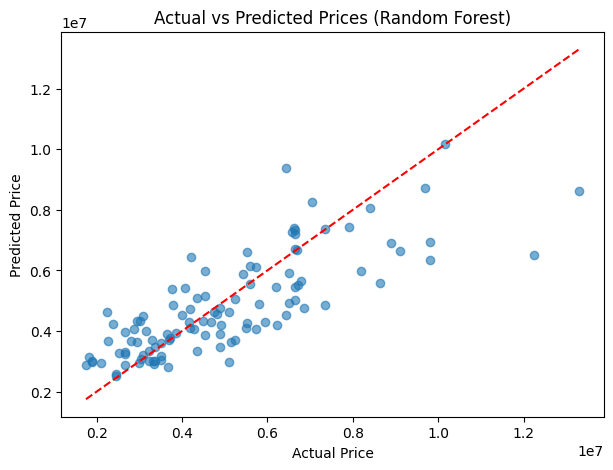

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()

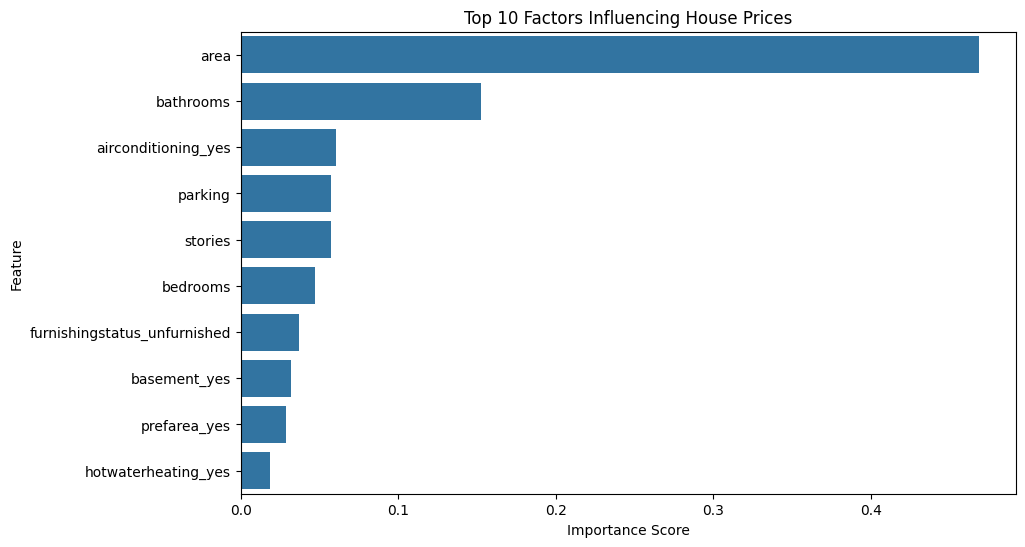

In [13]:
feature_importance = pd.DataFrame({'Feature': x.columns, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Factors Influencing House Prices')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

Insights & Summary

The analysis shows that area, bathrooms, air conditioning, parking availability, and preferred area status have the strongest influence on house prices. Among the two models tested, Linear Regression performed better, achieving an R² score of approximately 0.65, which means it explains about 65% of the variation in house prices. One interesting observation was that some amenities such as air conditioning and location preference had a significant impact on price, sometimes more than the number of bedrooms. Based on these findings, a real estate business should focus on highlighting property size, location advantages, parking facilities, and modern amenities when marketing homes, as these factors contribute strongly to property value.